# __Обучение трансформер модели типа BERT__

### __для выявления позитивных и негативных отзывов__

In [1]:
import pandas as pd
import numpy as np

__Работать буду с датасетом отзывов на фильмы и сериалы на платформе Кинопоиск__

ссылка на датасет: https://huggingface.co/datasets/zloelias/kinopoisk-reviews

In [2]:
splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/zloelias/kinopoisk-reviews/" + splits["train"])

c:\Users\Ilya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df

,text,labels,label_name,__index_level_0__
0,Смотрел данный фильм ещё в глубоком детстве. И...,1,negative,12149
1,"После того, как третья часть оригинальной исто...",0,positive,1089
2,Сериал очень нравится. Смотрела все три сезона...,0,positive,24367
3,"Лично мне понравилось. Конечно не шедевр, но в...",0,positive,3060
4,Неторопливая интеллигентная английская драма и...,0,positive,23560
...,...,...,...,...
73815,На Новый год купила себе книгу 'Прекрасные соз...,1,negative,6443
73816,Данный фильм считается чуть ли не киношедевром...,1,negative,15775
73817,"Стараюсь смотреть всё, что связано с религией ...",1,negative,9640
73818,"Сначала о том немногом хорошем, что есть в фил...",1,negative,14468


Удалю ненужные столбцы

In [4]:
df = df.drop(columns = ['label_name', '__index_level_0__'])
df

,text,labels
0,Смотрел данный фильм ещё в глубоком детстве. И...,1
1,"После того, как третья часть оригинальной исто...",0
2,Сериал очень нравится. Смотрела все три сезона...,0
3,"Лично мне понравилось. Конечно не шедевр, но в...",0
4,Неторопливая интеллигентная английская драма и...,0
...,...,...
73815,На Новый год купила себе книгу 'Прекрасные соз...,1
73816,Данный фильм считается чуть ли не киношедевром...,1
73817,"Стараюсь смотреть всё, что связано с религией ...",1
73818,"Сначала о том немногом хорошем, что есть в фил...",1


In [5]:
test = pd.read_parquet("hf://datasets/zloelias/kinopoisk-reviews/" + splits["test"])

In [6]:
test

,text,labels,label_name,__index_level_0__
0,"Против воли никто никого не спасет,\nИ застави...",0,positive,5815
1,"Грязное, мерзкое зрелище. После просмотра жале...",1,negative,9739
2,"Expert, texpert choking smokers\nDon't you thi...",1,negative,11892
3,До определённого времени никто не знал имени т...,0,positive,85297
4,Предыстория: Алек Гиллис всю жизнь занимался с...,0,positive,83701
...,...,...,...,...
8198,На этот фильм я наткнулась совершенно случайно...,1,negative,5876
8199,Фильм слащаво-приторный и слишком прямолинейны...,1,negative,10786
8200,"17-й век, местные жители терроризируют еврейск...",1,negative,12495
8201,"Когда я впервые увидела сериал по телевизору, ...",0,positive,55264


In [7]:
df.labels.value_counts()

labels
0    47071
1    26749
Name: count, dtype: int64

__Удалю дубликаты и посмотрю на конечное распределение классов__

In [8]:
print(f"Кол-во дупликатов: {df['text'].duplicated().sum()}")

#Удалим дубликаты
df_new = df.drop_duplicates(['text'], keep='first')

print(f"Распределение классов у таргета: {df_new['labels'].value_counts()}")

Кол-во дупликатов: 22848
Распределение классов у таргета: labels
0    36384
1    14588
Name: count, dtype: int64


### В датасете было огромное число дубликатов

In [9]:
df_test = test.drop_duplicates(['text'], keep = 'first')

print(f"Распределение классов у таргета в тестовом датасете: {df_test['labels'].value_counts()}")

Распределение классов у таргета в тестовом датасете: labels
0    5044
1    2791
Name: count, dtype: int64


__Проведу обычное сплитование с помощью train_test_split__

In [10]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df_new, test_size= .1, stratify= df_new['labels'], random_state= 42)

In [11]:
print(f"\nОбщий размер: {len(df_new) + len(df_test)} отзывов")
print(f"\nРазмеры выборок:")
print(f"  Train:      {len(df_train)} ({len(df_train)/len(df_new)*100:.1f}%)")
print(f"  Validation: {len(df_val)}   ({len(df_val)/len(df_new)*100:.1f}%)")
print(f"  Test:       {len(df_test)}  ({len(df_test)/len(df_new)*100:.1f}%)")

print(f"\nРаспределение классов на train:")
print(df_train['labels'].value_counts(normalize=True).sort_index())


Общий размер: 58807 отзывов

Размеры выборок:
  Train:      45874 (90.0%)
  Validation: 5098   (10.0%)
  Test:       7835  (15.4%)

Распределение классов на train:
labels
0    0.713803
1    0.286197
Name: proportion, dtype: float64


## __Перейду к обучению модели__

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
from tqdm.auto import tqdm
import os
import random
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

__Глобальные параметры__

In [13]:
MODEL_NAME = 'intfloat/multilingual-e5-small'
BATCH_SIZE = 128
MAX_LENGTH = 256
NUM_EPOCHS = 10
RANDOM_SEED = 42

In [14]:
def seed_all(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(RANDOM_SEED)

In [15]:
# Инициализируем токенизатор
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Пример энкодингов токенизатора

In [16]:
text = 'Тренировочный текст для просмотры работы токенизатора. Рандомный стек слов, чтобы было'

encode = tokenizer(
    text,
    truncation = True,
    padding ='max_length',
    max_length = MAX_LENGTH,
    return_tensors ='pt'
)
print(encode)

{'input_ids': tensor([[     0, 142509,  43996, 143043,  13587,    518, 213892,    227,   8979,
            690,  14564, 146325,     59,      5, 121186,  29471,   2192,  89404,
          48355,      4,   3077,   2120,      2,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              

__Интересная библиотека termcolor, которая позволит посмотреть на токены в _красках___

In [17]:
from termcolor import colored

tokens = tokenizer.convert_ids_to_tokens(encode['input_ids'][0])
attention_mask = encode['attention_mask'][0]
input_ids = encode['input_ids'][0].tolist()

# Собираем только полезные токены (без PAD)
real_tokens = [t for t, m in zip(tokens, attention_mask) if m == 1]
real_ids = [id_ for id_, m in zip(input_ids, attention_mask) if m == 1]

# Цвета для чередования
colors = ['red', 'green', 'yellow', 'blue', 'magenta', 'cyan', 'white']

# Заголовок с номерами токенов
print("\n№ токена:  ", end='')
for i in range(len(real_tokens)):
    print(colored(f'{i:^7}', 'white'), end='')
print()

# Разделитель
print("           " + "─"*7 * len(real_tokens))

# Строка с токенами
print("Токены:    ", end='')
for i, token in enumerate(real_tokens):
    color = colors[i % len(colors)]
    display = token.replace('▁', '_')
    print(colored(f'{display:^7}', color), end='')
print()

# Строка с ID токенов
print("ID:        ", end='')
for i, token_id in enumerate(real_ids):
    color = colors[i % len(colors)]
    print(colored(f'{token_id:^7}', color), end='')
print()


№ токена:     0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17     18     19     20     21     22   
           ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Токены:      <s>   _Трен  иров   очный _текст  _для  _просмотр   ы   _работы  _то    кен  изатор    а      .    _Ран    дом    ный   _стек  _слов    ,   _чтобы  _было  </s>  
ID:           0   142509  43996 143043  13587   518  213892   227   8979    690   14564 146325   59      5   121186  29471  2192   89404  48355    4    3077   2120     2   


In [18]:
#Создадим класс Dataset
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_length = 128):
        self.texts = df['text'].tolist()
        self.labels = df['labels'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype= torch.float)
        }

In [19]:
#Создаем все необходимые датасеты
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = TextDataset(df_train, tokenizer, MAX_LENGTH)

val_dataset = TextDataset(df_val, tokenizer, MAX_LENGTH)

test_dataset = TextDataset(df_test, tokenizer, MAX_LENGTH)

In [20]:
#Пример
train_dataset[1]

{'input_ids': tensor([     0,   1087,  59342,   9888,    380,      4, 184249, 183997,    242,
         151275,      4, 106968,     38,     25,     20,  62936, 212262,  16117,
          12635, 184249, 183997,      5,    672, 117811,   8118, 184249,  16975,
             89,   7836,  66794,    698,  93382, 174001, 215951,    129,  44004,
           1117,    829,    312,   2351,      5,   1851, 120023,     77,   1145,
          34295,     35,  52061,     35,   9765,     77,  60229,  26287,  29776,
          37793,     35, 189861,  32915,  45939,    130,   3455,      5,    417,
          68642,    129,    695,   8870, 118176,    129, 188161,     49,  14468,
             89,  77892,  33111,     15, 100753,  22598,    380,  66794,    698,
            194,   4619,     35,   3549, 152249,    245,  27135,   2033,  63640,
         184249, 183997,     59,      5,  52175,  30687, 207467,    591,  18954,
            928, 120235,   2519,      5,    672,  32394,    135,  66794,    415,
              5

In [21]:
#Создадим даталоадеры
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [22]:
batch = next(iter(train_loader))
batch["input_ids"].shape

torch.Size([128, 256])

In [23]:
len(train_loader)

359

#### __Создание класса модели__

Модель типа RoBERTa model, где в классификатор будут подаваться агрегированные векторы всех слов для выдачи ответа с помощью функции сигмоиды

In [24]:
class E5Classifier(nn.Module):
    def __init__(self, model_name='intfloat/multilingual-e5-small'):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name)
        print("embed_dim = ", self.model.config.hidden_size)
        self.classifier = nn.Linear(self.model.config.hidden_size, 1) # бинарная классификация
        
    def mean_pooling(self, token_embeddings, attention_mask):
        """Усреднение векторов всех токенов кроме padding"""
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(
            token_embeddings.size()
        ).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        return sum_embeddings / sum_mask
        
    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        
        # Average pooling
        pooled_output = self.mean_pooling(
            outputs.last_hidden_state, 
            attention_mask
        )
        
        logits = self.classifier(pooled_output)
        return logits.squeeze(-1)

In [25]:
# Инициализируем модель
model = E5Classifier(model_name=MODEL_NAME)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3326.88it/s]
BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embed_dim =  384


In [26]:
model

E5Classifier(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250037, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_af

In [27]:
# Функция для вычисления числа параметров
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

count_parameters(model)

(117654145, 117654145)

In [28]:
# Функция для вычисления метрик
def compute_metrics(predictions, labels, threshold=0.5):
    predictions_binary = (predictions > threshold).astype(int)
    accuracy = accuracy_score(labels, predictions_binary)
    f1 = f1_score(labels, predictions_binary)
    precision = precision_score(labels, predictions_binary)
    recall = recall_score(labels, predictions_binary)
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

FocalLoss для работы несбалансированными классами

Но у нас достаточно умеренная ситуация, поэтому при обучении модели я дал небольшой __"приоритет"__ для негативных отзывов

In [33]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0, reduction: str = "mean"):
        """
        Focal Loss для бинарной классификации.
        
        Parameters
        ----------
        alpha : torch.Tensor
            Веса классов размером [2] для [класс_0, класс_1].
            Пример: torch.tensor([0.75, 0.25])
        gamma : float
            Параметр фокусировки. По умолчанию 2.0.
        reduction : str
            'mean', 'sum' или 'none'.
        """
        super().__init__()
        # Гарантируем, что alpha — это тензор с плавающей точкой
        self.alpha = alpha.float()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        inputs : torch.Tensor
            Логиты модели (без сигмоиды), форма [Batch, ...]
        targets : torch.Tensor
            Метки классов (0 или 1), форма [Batch, ...]
        """
        assert inputs.shape == targets.shape, f"Shape mismatch: {inputs.shape} vs {targets.shape}"
        
        # Приводим targets к long для gather и float для BCE
        targets_long = targets.long()
        targets_float = targets.float()

        # 1. Бинарная кросс-энтропия без редукции
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets_float, reduction="none"
        )

        # 2. Вероятность правильного класса (p_t)
        p_t = torch.exp(-bce_loss)

        # 3. Выбор веса alpha для каждого пикселя/элемента
        # Перемещаем alpha на то же устройство, что и данные
        alpha = self.alpha.to(inputs.device)
        
        # gather выбирает вес: если target=0 -> alpha[0], если target=1 -> alpha[1]
        alpha_t = alpha.gather(0, targets_long.view(-1)).view_as(targets)

        # 4. Фокусирующий коэффициент (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma

        # 5. Итоговый лосс
        loss = alpha_t * focal_weight * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

__Функции тренировки и оценки нашей модели__

Из интересного warmup шедулер

In [29]:
def train_model(model, train_loader, val_loader, device, num_epochs=5):
    model.to(device)
    
    # Инициализация оптимизатора, функции потерь и планировщика
    # Расчет параметров
    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(0.05 * total_steps)  # 5% warmup

    loss_func = FocalLoss(
        alpha=torch.tensor([0.5, 1.0]), 
        gamma=2.5
    )

    optimizer = AdamW(
        model.parameters(), 
        lr=3e-5, 
        weight_decay=0.01
    )

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps, 
        num_training_steps=total_steps
    )
    
    # Списки для сохранения истории лоссов (для построения графиков)
    train_losses = []
    val_losses = []
    
    best_val_f1 = 0
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        
        # --- TRAIN ---
        model.train()
        total_train_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Training', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = loss_func(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()
        
        train_losses.append(total_train_loss / len(train_loader))
        
        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0
        val_predictions = []
        val_labels = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Validation', leave=False):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                
                outputs = model(input_ids, attention_mask)
                
                # Считаем лосс валидации для графика
                loss = loss_func(outputs, labels)
                total_val_loss += loss.item()
                
                # Предсказания нужны только для расчета F1 (отбор лучшей модели)
                predictions = torch.sigmoid(outputs).cpu().numpy()
                val_predictions.extend(predictions)
                val_labels.extend(labels.cpu().numpy())
        
        val_losses.append(total_val_loss / len(val_loader))
        
        # Расчет метрик только для условия сохранения
        val_metrics = compute_metrics(np.array(val_predictions), np.array(val_labels))
        current_f1 = val_metrics['f1']
        val_acc = val_metrics['accuracy']
        
        print(f'Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val accuracy: {val_acc:.3f} | Val F1: {current_f1:.3f}')
        
        if current_f1 > best_val_f1:
            best_val_f1 = current_f1
            torch.save(model.state_dict(), 'best_model.pth')
            print("Model weights updated due to improved validation F1 score")
    
    print(f'\nTraining Complete. Best validation F1: {best_val_f1:.4f}')
    
    # Возвращаем модель и историю лоссов
    return model, train_losses, val_losses

In [31]:
""" # Запуск обучения 
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

final_model, train_l, val_l = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
)
"""

" # Запуск обучения \ndevice = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')\n\nfinal_model, train_l, val_l = train_model(\n    model=model,\n    train_loader=train_loader,\n    val_loader=val_loader,\n    device=device,\n    num_epochs=NUM_EPOCHS,\n)\n"

### Поработаем с нашей обученной моделью

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Загружаем лучшую модель для финального тестирования
model.load_state_dict(torch.load('best_model.pt', map_location=device))

model.to(device).eval()

final_predictions = []
final_labels = []

# Сбор предсказаний на тестовом наборе
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids, attention_mask)
        predictions = torch.sigmoid(outputs).cpu().numpy()
        
        final_predictions.extend(predictions)
        final_labels.extend(labels.cpu().numpy())

# Конвертация в массивы
final_predictions = np.array(final_predictions).ravel()  # Важно: flatten для бинарной задачи
final_labels = np.array(final_labels).ravel()

Device: cpu


100%|██████████| 62/62 [08:59<00:00,  8.70s/it]


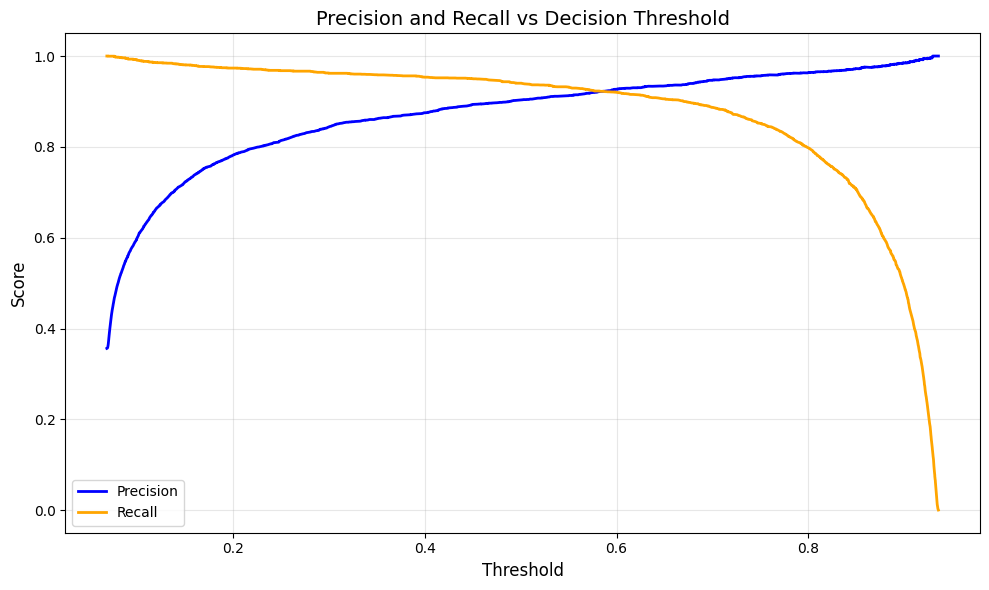

In [36]:
# --- Precision-Recall vs Threshold ---
# Расчет метрик для разных порогов
precisions, recalls, thresholds = precision_recall_curve(final_labels, final_predictions)

# Построение графика зависимости от порога
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2, color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2, color='orange')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision and Recall vs Decision Threshold', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

__Пересечение кривых видно примерно на 0.58 порога__

Поработаю сейчас с порогом 0.5, потом посмотрю метрики на пороге 0.58


CLASSIFICATION REPORT (threshold=0.5)
              precision    recall  f1-score   support

         0.0     0.9661    0.9445    0.9552      5044
         1.0     0.9036    0.9402    0.9215      2791

    accuracy                         0.9429      7835
   macro avg     0.9349    0.9423    0.9383      7835
weighted avg     0.9439    0.9429    0.9432      7835


CONFUSION MATRIX (threshold=0.5)


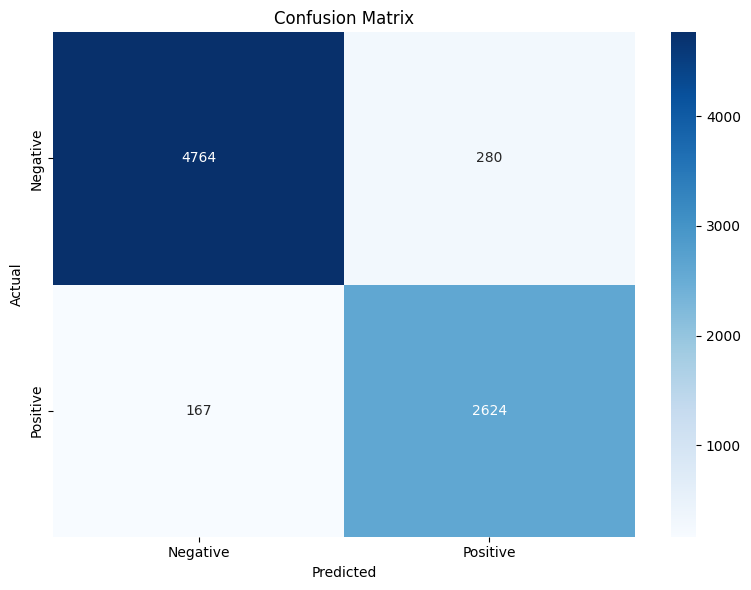

In [37]:
# Бинаризация предсказаний для основных метрик
threshold = 0.5
final_predictions_binary = (final_predictions > threshold).astype(int)

# --- Classification Report ---
print('\n' + '='*50)
print(f'CLASSIFICATION REPORT (threshold={threshold})')
print('='*50)
print(classification_report(final_labels, final_predictions_binary, digits=4))

# --- Confusion Matrix ---
print('\n' + '='*50)
print(f'CONFUSION MATRIX (threshold={threshold})')
print('='*50)
cm = confusion_matrix(final_labels, final_predictions_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


CLASSIFICATION REPORT (threshold=0.58)
              precision    recall  f1-score   support

         0.0     0.9573    0.9560    0.9567      5044
         1.0     0.9207    0.9230    0.9218      2791

    accuracy                         0.9442      7835
   macro avg     0.9390    0.9395    0.9392      7835
weighted avg     0.9443    0.9442    0.9442      7835


CONFUSION MATRIX (threshold=0.58)


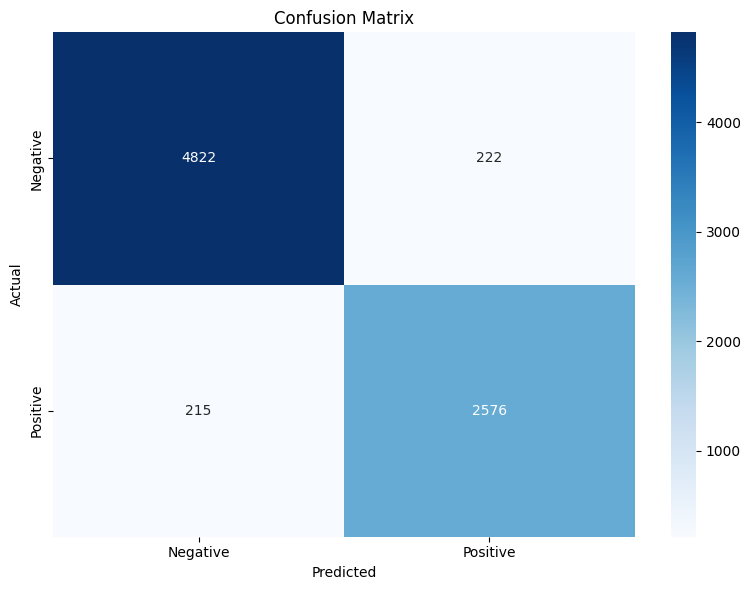

In [44]:
# Бинаризация предсказаний для основных метрик
threshold = 0.58
final_predictions_binary = (final_predictions > threshold).astype(int)

# --- Classification Report ---
print('\n' + '='*50)
print(f'CLASSIFICATION REPORT (threshold={threshold})')
print('='*50)
print(classification_report(final_labels, final_predictions_binary, digits=4))

# --- Confusion Matrix ---
print('\n' + '='*50)
print(f'CONFUSION MATRIX (threshold={threshold})')
print('='*50)
cm = confusion_matrix(final_labels, final_predictions_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [38]:
# Добавляем столбцы в датафрейм
df_test['model_score'] = final_predictions
df_test['predicted_label'] = (final_predictions > 0.5).astype(int)

# Выводим примеры FP (ложные срабатывания)
fp_df = df_test[(df_test['predicted_label'] == 1) & (df_test['labels'] == 0)]
print(f"\nFalse Positives (FP): {len(fp_df)}")
print("="*80)
for idx, row in fp_df.sample(min(5, len(fp_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Positives (FP): 1871
СКОР от модели: 0.9105
ТЕКСТ: Трудно представить более несовместимых людей, чем Стефано (Лука Арджентеро) и Клаудия (Сара Фербельбаум), он семейный психолог и весьма хороший, она адвокат по разводам и злобная как акула. Так случил...
--------------------------------------------------------------------------------
СКОР от модели: 0.9300
ТЕКСТ: Hello, I’m Johnny Cash

Долго не мог собраться с силами и посмотреть этот фильм: слишком уж велика фигура «Человека в черном». Часто бывает так, что в байопиках берутся за показ всего жизненно пути ге...
--------------------------------------------------------------------------------
СКОР от модели: 0.8865
ТЕКСТ: Я уже неоднократно рассказывал всем друзьям и знакомым о фильме 'Пацаны'. Рассказывал, рассказываю и буду рассказывать - потому что фильм этот по-настоящему искренний, правдивый, настоящий. И он рвет ...
--------------------------------------------------------------------------------
СКОР от модели: 0.8783
ТЕКС

In [39]:
# Выводим примеры FN (пропущенные цели)
fn_df = df_test[(df_test['predicted_label'] == 0) & (df_test['labels'] == 1)]
print(f"\nFalse Negatives (FN): {len(fn_df)}")
print("="*80)
for idx, row in fn_df.sample(min(5, len(fn_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Negatives (FN): 1758
СКОР от модели: 0.0847
ТЕКСТ: Не стану отрицать, я смотрел 'Простоквашино' в детстве. Это был один из немногих мультфильмов советского производства, которые я видел и которые мне, определенно нравились. Мое детство было буквально ...
--------------------------------------------------------------------------------
СКОР от модели: 0.0785
ТЕКСТ: Видимо такова моя судьба - обличать плохих режиссёров. Всё, что можно сказать про этот сериал: 'Экранизация...' (скорчив недовольную мину, ну типа вы понимаете, что тут ничего хорошего ждать не приход...
--------------------------------------------------------------------------------
СКОР от модели: 0.1943
ТЕКСТ: Откровенно неудачный мульт от Sony Pictures Animation. Может, создатели и пытались сделать настоящий мультблокбастер как у больших дядь (Dreamworks и Pixar), со взрослыми темами и острыми шутками, да ...
--------------------------------------------------------------------------------
СКОР от модели: 0.1057
ТЕКС

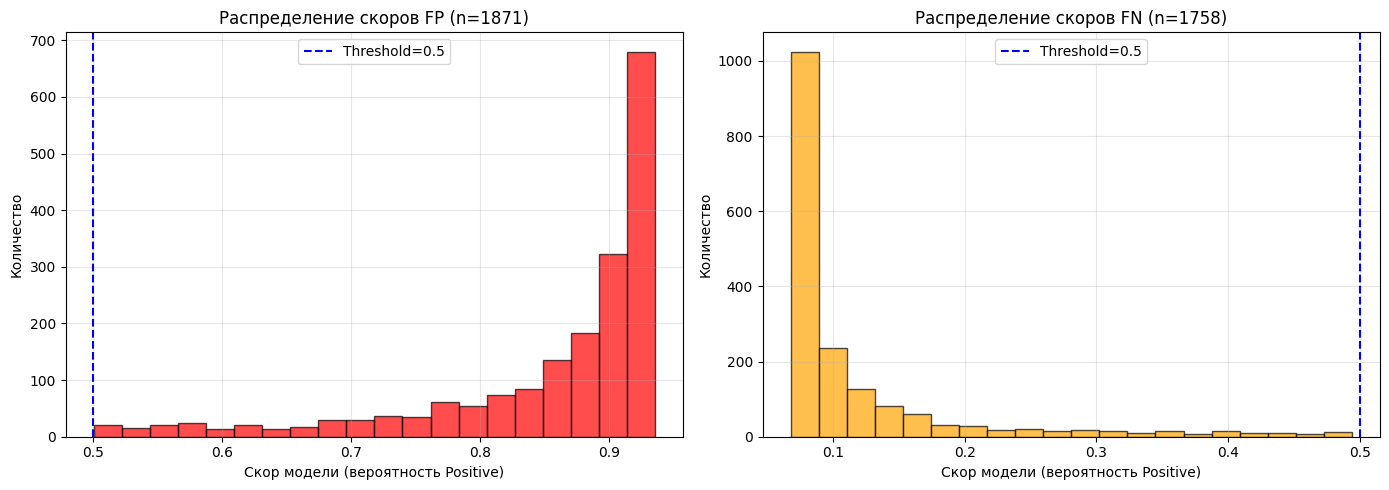

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение для FP
if len(fp_df) > 0:
    axes[0].hist(fp_df['model_score'], bins=20, alpha=0.7, color='red', edgecolor='black')
    axes[0].axvline(x=0.5, color='blue', linestyle='--', label='Threshold=0.5')
    axes[0].set_xlabel('Скор модели (вероятность Positive)')
    axes[0].set_ylabel('Количество')
    axes[0].set_title(f'Распределение скоров FP (n={len(fp_df)})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    

# Распределение для FN
if len(fn_df) > 0:
    axes[1].hist(fn_df['model_score'], bins=20, alpha=0.7, color='orange', edgecolor='black')
    axes[1].axvline(x=0.5, color='blue', linestyle='--', label='Threshold=0.5')
    axes[1].set_xlabel('Скор модели (вероятность Positive)')
    axes[1].set_ylabel('Количество')
    axes[1].set_title(f'Распределение скоров FN (n={len(fn_df)})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
plt.tight_layout()
plt.savefig('distribution_plot.png', dpi=300, bbox_inches='tight')  # Сохраняем перед show()
plt.show()

In [41]:
# Выводим примеры FN (пропущенные цели)
fn_df = df_test[(df_test['predicted_label'] == 0) & (df_test['labels'] == 1) & (df_test['model_score'] < 0.1)]
print(f"\nFalse Negatives (FN): {len(fn_df)}")
print("="*80)
for idx, row in fn_df.sample(min(3, len(fn_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Negatives (FN): 1157
СКОР от модели: 0.0754
ТЕКСТ: Этот фильм не заслуживает рецензии, но у меня личные цели, так что вот она.

Совершенно случайно побывала на этом, так сказать, фильме. Разумеется не по своей личной воле, ибо, будь у меня власть и де...
--------------------------------------------------------------------------------
СКОР от модели: 0.0780
ТЕКСТ: Доброго времени суток, уважаемые друзья! Уже стало традицией, что новые экранизации знаменитых произведений, которые уже общеизвестны и заслужили всеобщую любовь делают довольно посредственными. Один ...
--------------------------------------------------------------------------------
СКОР от модели: 0.0696
ТЕКСТ: 'У нее щупальца. Защупает насмерть!'

Как это ни странно, но легендарная киностудия 'The Asylum' не имеет к фильму Деклана О`Брайэна никакого отношения, хотя жанрово картина выполнена полностью в духе...
--------------------------------------------------------------------------------


In [42]:
# Функция для предсказания на новых данных
def predict_texts(model, tokenizer, texts, device):
    model.eval()
    predictions = []
    
    for text in texts:
        encoding = tokenizer(
            str(text),
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        
        with torch.no_grad():
            output = model(input_ids, attention_mask)
            prob = torch.sigmoid(output).cpu().item()
            predictions.append(prob)
    
    return predictions

### С помощью функции предсказания на новых данных, посмотрю работу модели на сгенерированных и собственных примерах

In [43]:
test_texts = [
    "Фильм оставил очень странное впечатление, с одной стороны визуально он выглядит потрясающе, но сюжет кажется затянутым и местами нелогичным. Актерская игра хорошая, но персонажи раскрыты не до конца, из-за чего сложно сопереживать.",
    
    "Отличная картина с сильной драматургией и глубокими персонажами. Особенно понравилась операторская работа и саундтрек, который идеально дополняет атмосферу. Финал оказался неожиданным и заставил задуматься.",
    
    "Это типичный развлекательный блокбастер, который не пытается быть чем-то большим. Много экшена, спецэффекты на уровне, но сюжет довольно шаблонный и предсказуемый. Смотреть можно, но без ожиданий.",
    
    "Фильм оказался намного лучше, чем я ожидал. История развивается плавно, персонажи живые и убедительные. Особенно понравился главный герой, его мотивация и внутренний конфликт показаны очень качественно.",
    
    "Слишком медленное повествование и перегруженность диалогами делают фильм скучным. Несмотря на интересную идею, реализация подкачала. Несколько сцен можно было бы спокойно вырезать без потери смысла.",
    
    "Очень атмосферное кино с красивой картинкой и отличной музыкой. Сюжет не самый оригинальный, но подача делает его увлекательным. После просмотра остается приятное послевкусие.",
    
    "Актерская игра на высшем уровне, особенно второстепенные персонажи получились яркими и запоминающимися. Однако сценарий местами проседает, и некоторые сюжетные линии выглядят недоработанными.",
    
    "Фильм удивил своей глубиной и философскими подтекстами. Он не для всех, требует внимательного просмотра, но если вникнуть, можно получить настоящее удовольствие и пищу для размышлений.",
    
    "Фильм шедевр! Меня удивил",

    "Унылая работа, не ожидал, что такую интересную и захватывающую историю, можно так мутно изложить"
]
predict_texts(model=model, tokenizer=tokenizer, texts=test_texts, device=device)

[0.20548973977565765,
 0.07068874686956406,
 0.5158273577690125,
 0.07228484749794006,
 0.9284285306930542,
 0.07215358316898346,
 0.15026222169399261,
 0.0711807981133461,
 0.09584455192089081,
 0.7360187768936157]

__Отработала более чем достойно__

### А теперь поглядим на влияние слов на предикт с помощью интересной библиотеки __lime__

In [ ]:
# !pip install lime

ERROR: Could not find a version that satisfies the requirement lime (from versions: none)
ERROR: No matching distribution found for lime


Probabilities: Neg=0.924, Pos=0.076
Predicted: Negative


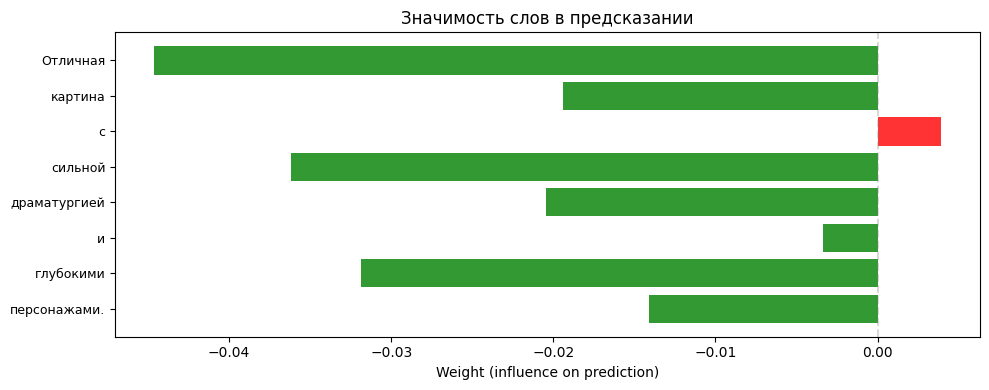

In [53]:
from lime.lime_text import LimeTextExplainer

def create_lime_predictor(model, tokenizer, device, max_length=512):
    model.eval()
    def predictor(texts):
        probs = []
        with torch.no_grad():
            for text in texts:
                enc = tokenizer(str(text), truncation=True, padding='max_length', 
                               max_length=max_length, return_tensors='pt')
                input_ids = enc['input_ids'].to(device)
                attention_mask = enc['attention_mask'].to(device)
                output = model(input_ids, attention_mask)
                prob_1 = torch.sigmoid(output).cpu().item()
                probs.append([1-prob_1, prob_1])
        return np.array(probs)
    return predictor

def plot_lime_explanation_original_order(explanation, text, top_n=10, figsize=(10, 4)):
    """Визуализация в порядке исходного текста"""
    # Получаем все слова с весами
    lime_dict = {word: weight for word, weight in explanation.as_list()}
    
    # Разбиваем исходный текст на слова (в оригинальном порядке)
    words_in_order = text.split()
    
    # Берём только те слова, для которых есть веса от LIME
    words = []
    weights = []
    for word in words_in_order:
        # Очищаем слово от знаков препинания для поиска
        clean_word = word.strip('.,!?;:')
        if clean_word in lime_dict and len(words) < top_n:
            words.append(word)
            weights.append(lime_dict[clean_word])
    
    colors = ['red' if w > 0 else 'green' for w in weights]
    
    plt.figure(figsize=figsize)
    plt.barh(range(len(words)), weights, color=colors, alpha=0.8)
    plt.yticks(range(len(words)), words, fontsize=9)
    plt.xlabel('Weight (influence on prediction)')
    plt.title(f'Значимость слов в предсказании')
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# --- Использование ---
predict_fn = create_lime_predictor(model, tokenizer, device, MAX_LENGTH)
class_names = ['Negative', 'Positive']
explainer = LimeTextExplainer(class_names=class_names)

text = "Отличная картина с сильной драматургией и глубокими персонажами."
explanation = explainer.explain_instance(text, predict_fn, num_samples=1000, top_labels=2)

# Результаты
print(f"Probabilities: Neg={explanation.predict_proba[0]:.3f}, Pos={explanation.predict_proba[1]:.3f}")
print(f"Predicted: {class_names[np.argmax(explanation.predict_proba[0])]}")
plot_lime_explanation_original_order(explanation, text)

цвет изменил наглядно, так как зеленый ассоциируется с чем-то положительным, хотя веса отрицательные, так как это негативный класс

### С помощью данной визуализации можно четко отсмотреть какие слова двигают предсказания классификатора в ту или иную сторону

Probabilities: Neg=0.727, Pos=0.273
Predicted: Positive


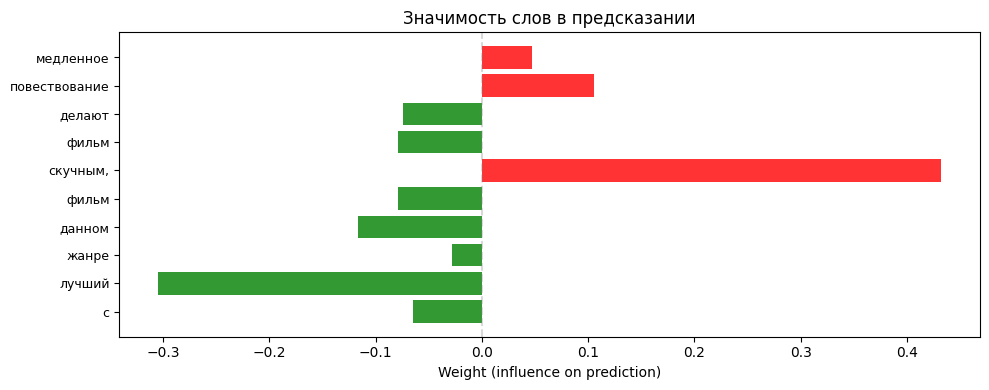

In [54]:
# --- Использование ---
predict_fn = create_lime_predictor(model, tokenizer, device, MAX_LENGTH)
class_names = ['Positive', 'Negative']
explainer = LimeTextExplainer(class_names=class_names)

text = "Слишком медленное повествование и перегруженность диалогами делают фильм скучным, фильм в данном жанре лучший с конца!"
explanation = explainer.explain_instance(text, predict_fn, num_samples=1000, top_labels=2)

# Результаты
print(f"Probabilities: Neg={explanation.predict_proba[0]:.3f}, Pos={explanation.predict_proba[1]:.3f}")
print(f"Predicted: {class_names[np.argmax(explanation.predict_proba[0])]}")
plot_lime_explanation_original_order(explanation, text)

### __Экспорт в ONNX формат__

In [56]:
# Создаем обертку для модели, которая добавляет reshape
class ModelWithReshape(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.original_model = original_model
    
    def forward(self, input_ids, attention_mask):
        output = self.original_model(input_ids, attention_mask)
        # Добавляем размерность: [batch] -> [batch, 1]
        output = output.unsqueeze(-1)  # или output.reshape(-1, 1)
        return output

# Конвертация с оберткой
def convert_to_onnx(model, tokenizer, device, output_path="model.onnx", max_length=64):
    model.eval()
    
    # Оборачиваем модель
    wrapped_model = ModelWithReshape(model)
    wrapped_model.eval()
    
    dummy_text = "dummy text for onnx export"
    dummy_inputs = tokenizer(dummy_text, truncation=True, padding='max_length', 
                            max_length=max_length, return_tensors='pt')
    
    dummy_input_ids = dummy_inputs['input_ids'].to(device)
    dummy_attention_mask = dummy_inputs['attention_mask'].to(device)
    
    # Экспортируем обернутую модель
    torch.onnx.export(
        wrapped_model,  # используем обертку
        (dummy_input_ids, dummy_attention_mask),
        output_path,
        input_names=['input_ids', 'attention_mask'],
        output_names=['output'],
        dynamic_axes={
            'input_ids': {0: 'batch_size'},
            'attention_mask': {0: 'batch_size'},
            'output': {0: 'batch_size'} 
        },
        opset_version=14
    )
    
    print(f"Модель с выходом размерности [batch, 1] сохранена в {output_path}")
    
# Сохраняем модель
convert_to_onnx(model, tokenizer, device, "model.onnx", MAX_LENGTH)

W0329 02:00:17.674000 10792 site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0329 02:00:19.268000 10792 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0329 02:00:19.270000 10792 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_sc

[torch.onnx] Obtain model graph for `ModelWithReshape([...]` with `torch.export.export(..., strict=False)`...


W0329 02:00:23.014000 10792 site-packages\torch\fx\experimental\symbolic_shapes.py:6833] _maybe_guard_rel() was called on non-relation expression Eq(s43, 1) | Eq(s72, s43)


[torch.onnx] Obtain model graph for `ModelWithReshape([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\Ilya\AppData\Local\Programs\Python\Python313\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "c:\Users\Ilya\AppData\Local\Programs\Python\Python313\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "c:\Users\Ilya\AppData\Local\Programs\Python\Python313\Lib\site-packages\onnxscript\version_converter\__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\Ilya\AppData\Local\Programs\Python\Python313\

Applied 55 of general pattern rewrite rules.
Модель с выходом размерности [batch, 1] сохранена в model.onnx
